# Hierarchial Clustering


We will use beer data to perform hierarchial clustering using
`AgglomerativeClustering` from `sklearn.cluster`.

* More about it: http://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html#sklearn.cluster.AgglomerativeClustering



The other option to seaborn packages `clustermap`. This function derives some features from `scipy` package.

* Refer to http://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html for reference to available methods on hierarchial clustering.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
import os
%matplotlib inline


## Preparing Data

Read data from a specified location


In [ ]:
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

In [2]:
from google.colab import drive
drive.mount('/content/files')

Mounted at /content/files


In [3]:
os.getcwd()

'/content'

In [4]:
path_name = "/content/files/MyDrive/ML_using_Python/Python_Code/"
os.chdir(path_name)
os.getcwd()

'/content/files/MyDrive/ML_using_Python/Python_Code'

In [3]:
raw_df = pd.read_csv( "Hclust_Beer data.csv",
                        sep = ',', na_values = ['#NA', '', '$$'])

raw_df.columns = raw_df.columns.str.lower().str.replace(' ', '_')
raw_df

,id,beer,cal,sod,alc,cost
0,1,Budweiser,144,15,4.7,0.43
1,2,Schlitz,151,19,4.9,0.43
2,3,Lowenbrau,157,15,4.9,0.48
3,4,Kronenbourg,170,7,5.2,0.73
4,5,Heineken,152,11,5.0,0.77
5,6,Old Mil,145,23,4.6,0.28
6,7,Augsburger,175,24,5.5,0.40
7,8,Strohs,149,27,4.7,0.42
8,9,Miller lite,99,10,4.3,0.43
9,10,Bud light,113,8,3.7,0.44


In [4]:
raw_df.corr()

ValueError: could not convert string to float: 'Budweiser'

In [6]:
?pd.read_csv

The referening of a row or column can be changed by using the below code chunk. Uncomment and change the values within `iloc` to understand how referencing works:

In [ ]:
#ref_row_col = raw_df.iloc[:,:]
#ref_row_col


## Extract Features and Standardize

Two ways to extract the features:

> * use `pd.filter` and pass the list of features to extract for scaling
* Use `pd.drop` and pass the list of features which need not be extracted

The feature can also be extracted by using `dataframeName[[<name of features>]]`


In [5]:
#feature_df = raw_df[['cal', 'sod', 'alc', 'cost']]

feature_df = raw_df.drop({'id','beer'}, axis =1)

#col_names
col_names = feature_df.columns

#row_index
row_index = raw_df.iloc[:,1]


## Scale the data

We can do so by using StandardScaler function from sk.learn preprocessing module. StandardScaler performs standarization by computing $\frac{x-\mu}{\sigma}$ for every feature.

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

data_scaled = pd.DataFrame(scaler.fit_transform( feature_df ))

data_scaled.columns = col_names
data_scaled.index = row_index
data_scaled

,cal,sod,alc,cost
beer,,,,
Budweiser,0.393336,0.007795,0.351095,-0.470541
Schlitz,0.630693,0.631369,0.621168,-0.470541
Lowenbrau,0.834143,0.007795,0.621168,-0.114071
Kronenbourg,1.274950,-1.239354,1.026278,1.668282
Heineken,0.664602,-0.615780,0.756205,1.953459
Old Mil,0.427244,1.254943,0.216058,-1.539953
Augsburger,1.444491,1.410837,1.431387,-0.684423
Strohs,0.562877,1.878518,0.351095,-0.541835
Miller lite,-1.132535,-0.771673,-0.189051,-0.470541


Use `rename` function, in case renaming of a specific column or index is required

In [ ]:
#feature_df.rename(index={'Budweiser':'Bud'}, inplace=True)

## Understand the number of clusters to make using Dendrogram.

Ward’s method says that the distance between two clusters, A and B, is how much the sum of squares will increase when we merge them:

More at: https://jbhender.github.io/Stats506/F18/GP/Group10.html

With hierarchical clustering, the sum of squares starts out at zero (because every point is in its own cluster) and then grows as we merge clusters. Ward’s method keeps this growth as small as possible.

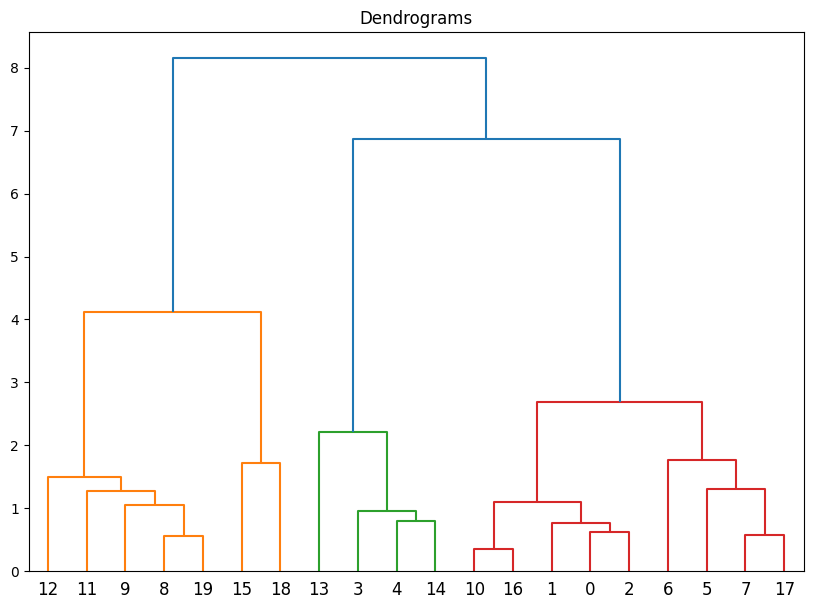

In [7]:
import scipy.cluster.hierarchy as shc
plt.figure(figsize=(10, 7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'))

The x-axis contains the samples and y-axis represents the distance between these samples. The distance in y axis gives a notion of the distances at which two clusters merged. The farther the distance (which means greater the vertical line), the more dissimilar the clusters are. The vertical line with maximum distance is the blue line and hence we can decide a threshold of 3 and cut the dendrogram.

**Note: Such visual technique can be misleading.** Using Silhoutte width as a metric to understand the number of cluster is better.

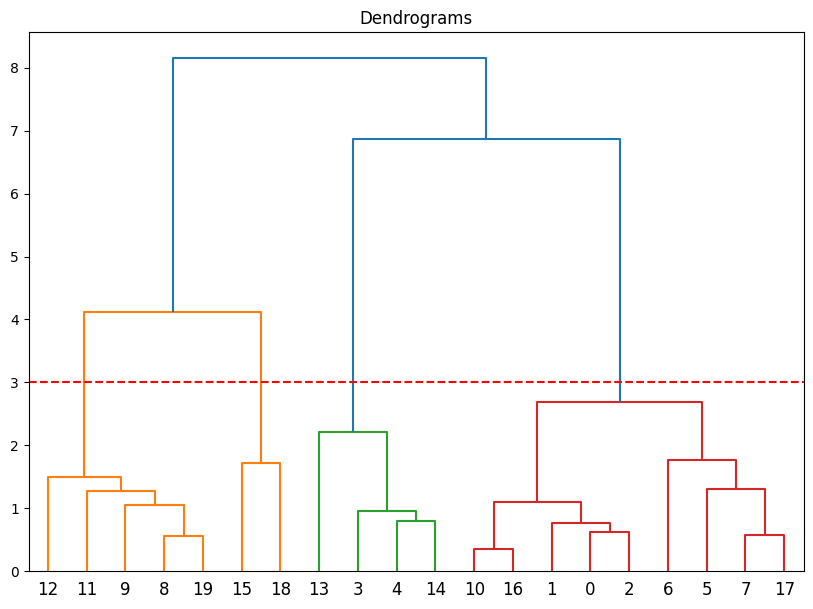

In [15]:
plt.figure(figsize=(10, 7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'))
plt.axhline(y=3, color='r', linestyle='--')

In [9]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=4, affinity='euclidean', linkage='ward')

TypeError: __init__() got an unexpected keyword argument 'affinity'

In [16]:
label = cluster.fit(data_scaled).labels_

#labels_
#label

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


In [18]:
raw_df['Cluster'] = label

raw_df

,id,beer,cal,sod,alc,cost,Cluster
0,1,Budweiser,144,15,4.7,0.43,0
1,2,Schlitz,151,19,4.9,0.43,0
2,3,Lowenbrau,157,15,4.9,0.48,0
3,4,Kronenbourg,170,7,5.2,0.73,2
4,5,Heineken,152,11,5.0,0.77,2
5,6,Old Mil,145,23,4.6,0.28,0
6,7,Augsburger,175,24,5.5,0.40,0
7,8,Strohs,149,27,4.7,0.42,0
8,9,Miller lite,99,10,4.3,0.43,3
9,10,Bud light,113,8,3.7,0.44,3


Brands which belong to cluster 0

In [19]:
np.where(label == 0)

(array([ 0,  1,  2,  5,  6,  7, 10, 16, 17]),)

We do not have test data to predict the cluster assignmet. But this is how it can be used to label new data.

In [20]:
hc_y = cluster.fit_predict(data_scaled)
hc_y

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


array([0, 0, 0, 2, 2, 0, 0, 0, 3, 3, 0, 3, 3, 2, 2, 1, 0, 0, 1, 3])


## Understand the number of clusters based on Silhoutte Width

In [21]:
from sklearn.metrics import silhouette_score
# Silhouette Score
for k in range(2,20):# Maximum range should be 20, as it contains only 20 beer brands
  cluster_H = AgglomerativeClustering(n_clusters=k,linkage= 'ward')
  model_clt = cluster_H.fit(data_scaled)
  label = model_clt.labels_
  sil_coeff = silhouette_score(data_scaled,label,metric = 'euclidean')
  print('For cluster= {}, Silhouette Coefficient is {}'.format(k,sil_coeff))


print('\n For Cluster = 3, it has highest Silhouette Value. So Number of Cluster = 3')

For cluster= 2, Silhouette Coefficient is 0.3609099742211978
For cluster= 3, Silhouette Coefficient is 0.482777660276389
For cluster= 4, Silhouette Coefficient is 0.47669889501956336
For cluster= 5, Silhouette Coefficient is 0.3960659538421393
For cluster= 6, Silhouette Coefficient is 0.37310142561356285
For cluster= 7, Silhouette Coefficient is 0.3717863047158899
For cluster= 8, Silhouette Coefficient is 0.32731331585613
For cluster= 9, Silhouette Coefficient is 0.2724494424955407
For cluster= 10, Silhouette Coefficient is 0.274543659697879
For cluster= 11, Silhouette Coefficient is 0.25790154017947886
For cluster= 12, Silhouette Coefficient is 0.2278978330068604
For cluster= 13, Silhouette Coefficient is 0.22791344962167207
For cluster= 14, Silhouette Coefficient is 0.1666435933519959
For cluster= 15, Silhouette Coefficient is 0.15340825701024316
For cluster= 16, Silhouette Coefficient is 0.13504058415041384
For cluster= 17, Silhouette Coefficient is 0.12001716328505374
For cluster= 

Dendrogram suggested 4 clusters.

## Exercise:

Use AgglomerativeClustering from sklearn.cluster to build Hierarchial Clustering using the cars data. What challenges do you encounter?